# Titanic — Estratégia 2: imputação por média e moda

Nesta versão:
- atributos numéricos com valores ausentes recebem a **média** do atributo.
- atributos nominais com valores ausentes recebem a **moda** do atributo.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("titanic completo.csv")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Dados ausentes

In [3]:
print("Dimensão original:", df.shape)
print("\nValores ausentes por atributo:")
print(df.isna().sum().sort_values(ascending=False))

Dimensão original: (1309, 14)

Valores ausentes por atributo:
body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
pclass          0
survived        0
name            0
sex             0
sibsp           0
parch           0
ticket          0
dtype: int64


## Imputação dos valores ausentes

In [4]:
df_tratado = df.copy()

colunas_numericas = df_tratado.select_dtypes(include="number").columns
colunas_nominais = df_tratado.select_dtypes(exclude="number").columns

for coluna in colunas_numericas:
    if df_tratado[coluna].isna().any():
        media = df_tratado[coluna].mean()
        df_tratado[coluna] = df_tratado[coluna].fillna(media)
        print(f"{coluna}: ausências preenchidas com média = {media:.4f}")

for coluna in colunas_nominais:
    if df_tratado[coluna].isna().any():
        moda = df_tratado[coluna].mode()[0]
        df_tratado[coluna] = df_tratado[coluna].fillna(moda)
        print(f"{coluna}: ausências preenchidas com moda = {moda}")

age: ausências preenchidas com média = 29.8811
fare: ausências preenchidas com média = 33.2955
body: ausências preenchidas com média = 160.8099
cabin: ausências preenchidas com moda = C23 C25 C27
embarked: ausências preenchidas com moda = S
boat: ausências preenchidas com moda = 13
home.dest: ausências preenchidas com moda = New York, NY


In [5]:
print("Dimensão após o tratamento:", df_tratado.shape)
print("Total de valores ausentes:", df_tratado.isna().sum().sum())

Dimensão após o tratamento: (1309, 14)
Total de valores ausentes: 0


## Visualizações

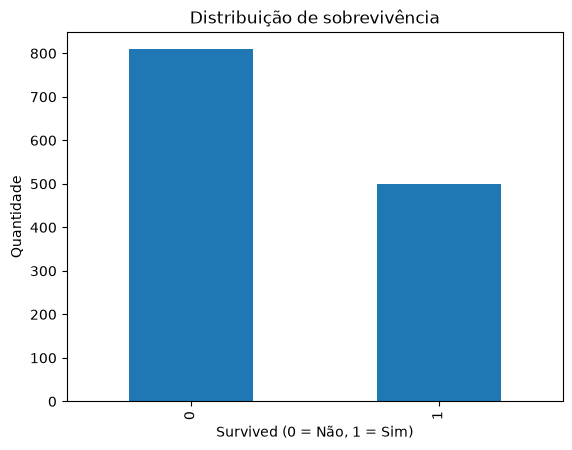

In [6]:
df_tratado["survived"].value_counts().sort_index().plot(
    kind="bar",
    title="Distribuição de sobrevivência"
)
plt.xlabel("Survived (0 = Não, 1 = Sim)")
plt.ylabel("Quantidade")
plt.show()

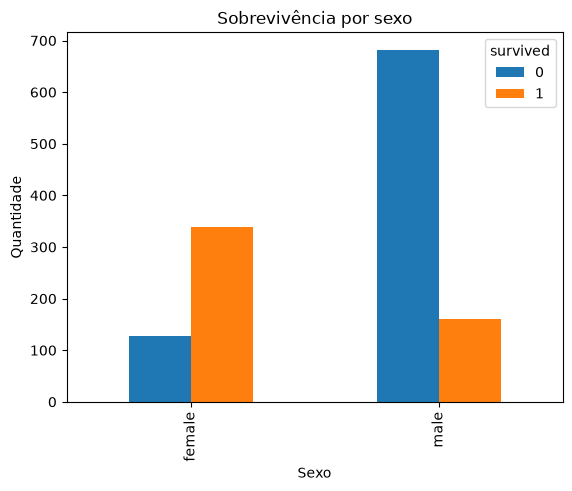

In [7]:
pd.crosstab(df_tratado["sex"], df_tratado["survived"]).plot(
    kind="bar",
    title="Sobrevivência por sexo"
)
plt.xlabel("Sexo")
plt.ylabel("Quantidade")
plt.show()

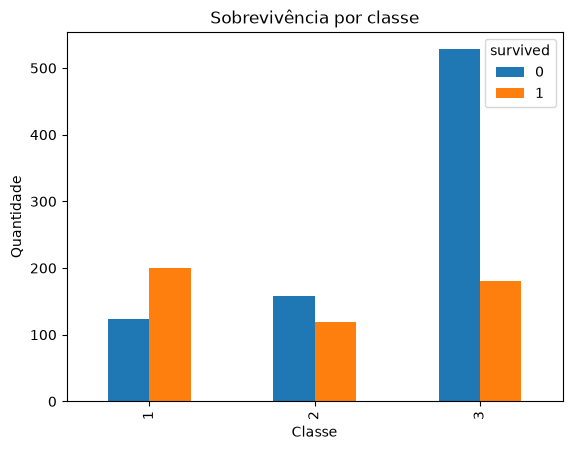

In [8]:
pd.crosstab(df_tratado["pclass"], df_tratado["survived"]).plot(
    kind="bar",
    title="Sobrevivência por classe"
)
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

## Preparação dos dados

Todos os atributos com ausência foram tratados por média ou moda.  
Para o treinamento, apenas `name` e `ticket` são retirados por funcionarem principalmente como identificadores.

In [9]:
X = df_tratado.drop(columns=["survived", "name", "ticket"])
y = df_tratado["survived"]

X = pd.get_dummies(X, drop_first=False, dtype=int)

print("Quantidade de atributos após codificação:", X.shape[1])
X.head()

Quantidade de atributos após codificação: 593


,pclass,age,sibsp,parch,fare,body,sex_female,sex_male,cabin_A10,cabin_A11,...,"home.dest_Wimbledon Park, London / Hayling Island, Hants","home.dest_Windsor, England New York, NY","home.dest_Winnipeg, MB","home.dest_Winnipeg, MN","home.dest_Woodford County, KY","home.dest_Worcester, England","home.dest_Worcester, MA","home.dest_Yoevil, England / Cottage Grove, OR","home.dest_Youngstown, OH","home.dest_Zurich, Switzerland"
0,1,29.00,0,0,211.3375,160.809917,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0.92,1,2,151.5500,160.809917,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2.00,1,2,151.5500,160.809917,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,30.00,1,2,151.5500,135.000000,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,25.00,1,2,151.5500,160.809917,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Divisão em treino e teste

In [10]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_treino.shape)
print("Teste:", X_teste.shape)

Treino: (1047, 593)
Teste: (262, 593)


## Árvore de decisão

In [11]:
arvore = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

arvore.fit(X_treino, y_treino)

y_pred = arvore.predict(X_teste)

print("Acurácia:", accuracy_score(y_teste, y_pred))
print("\nMatriz de confusão:")
print(confusion_matrix(y_teste, y_pred))
print("\nRelatório:")
print(classification_report(y_teste, y_pred, target_names=["Não sobreviveu", "Sobreviveu"]))

Acurácia: 0.9351145038167938

Matriz de confusão:
[[155   7]
 [ 10  90]]

Relatório:
                precision    recall  f1-score   support

Não sobreviveu       0.94      0.96      0.95       162
    Sobreviveu       0.93      0.90      0.91       100

      accuracy                           0.94       262
     macro avg       0.93      0.93      0.93       262
  weighted avg       0.93      0.94      0.93       262



## Visualização da árvore

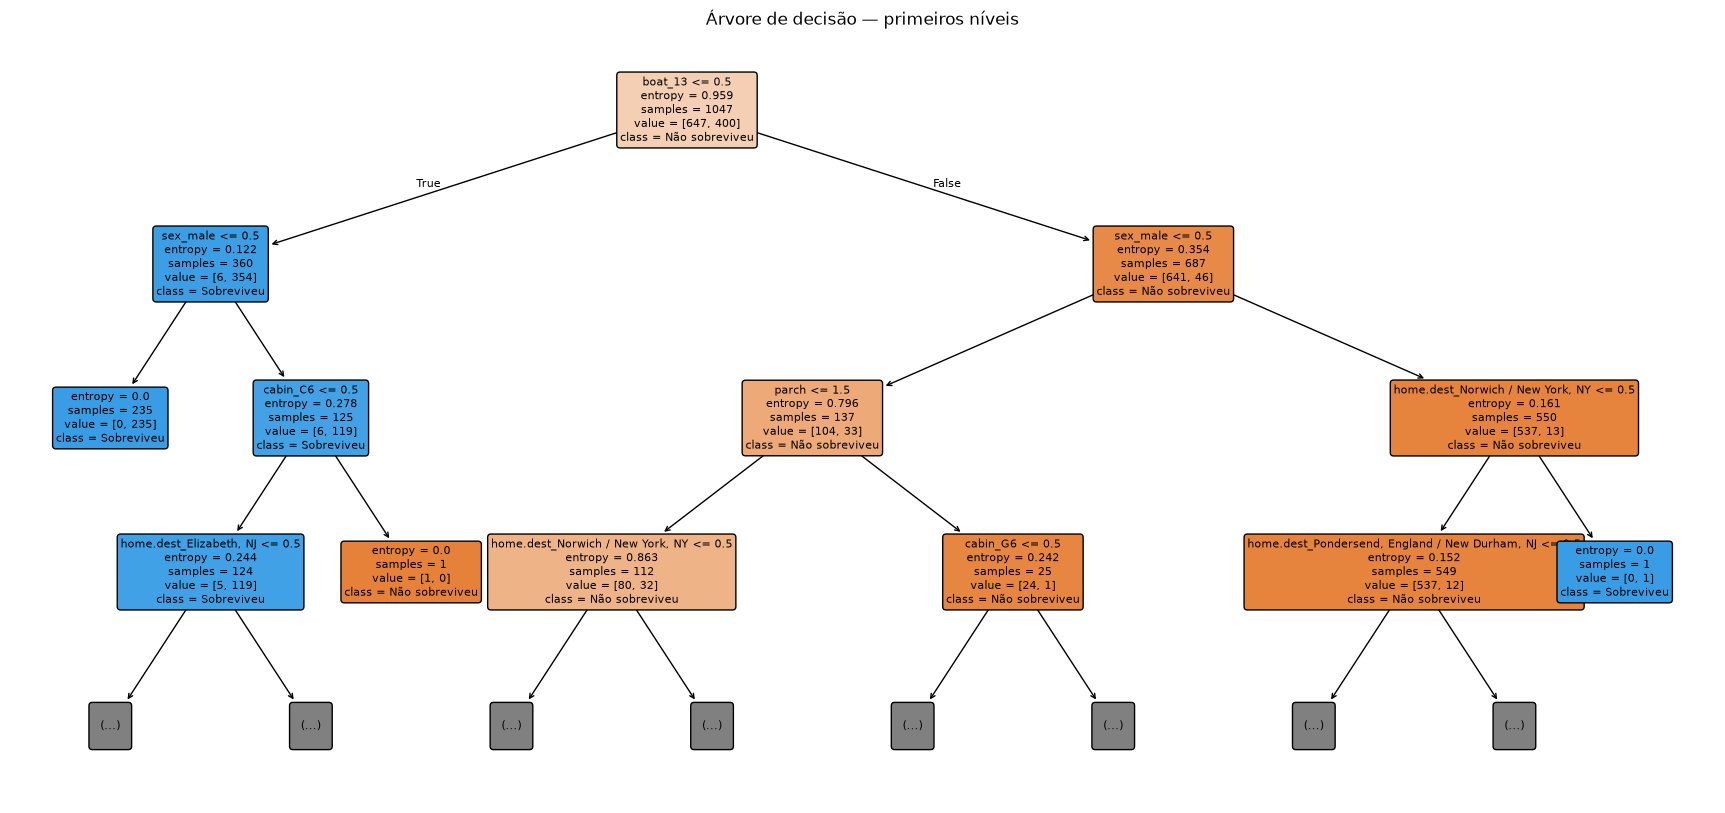

In [12]:
plt.figure(figsize=(22, 10))
plot_tree(
    arvore,
    feature_names=X.columns,
    class_names=["Não sobreviveu", "Sobreviveu"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Árvore de decisão — primeiros níveis")
plt.show()

## Regras da árvore

In [13]:
regras = export_text(
    arvore,
    feature_names=list(X.columns),
    max_depth=4
)
print(regras)

|--- boat_13 <= 0.50
|   |--- sex_male <= 0.50
|   |   |--- class: 1
|   |--- sex_male >  0.50
|   |   |--- cabin_C6 <= 0.50
|   |   |   |--- home.dest_Elizabeth, NJ <= 0.50
|   |   |   |   |--- home.dest_Ruotsinphytaa, Finland New York, NY <= 0.50
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |--- home.dest_Ruotsinphytaa, Finland New York, NY >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- home.dest_Elizabeth, NJ >  0.50
|   |   |   |   |--- class: 0
|   |   |--- cabin_C6 >  0.50
|   |   |   |--- class: 0
|--- boat_13 >  0.50
|   |--- sex_male <= 0.50
|   |   |--- parch <= 1.50
|   |   |   |--- home.dest_Norwich / New York, NY <= 0.50
|   |   |   |   |--- home.dest_Guntur, India / Benton Harbour, MI <= 0.50
|   |   |   |   |   |--- truncated branch of depth 15
|   |   |   |   |--- home.dest_Guntur, India / Benton Harbour, MI >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- home.dest_Norwich / New York, NY >  0.50
|   |   |   |   |--- class: 